In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [29]:
URL = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

print("Downloading OWID COVID-19 dataset...")
df = pd.read_csv(URL)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Dataset: 429,435 rows x 67 columns
Date range: 2020-01-01 to 2024-08-14


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [30]:
countries = ['India', 'United States', 'Brazil', 'United Kingdom']

d = df[df['location'].isin(countries)].copy()
d = d.sort_values(['location', 'date'])

# Ensure numeric fields are numeric
for col in ['new_cases', 'new_deaths', 'new_cases_smoothed', 'new_deaths_smoothed',
            'total_cases', 'total_deaths', 'people_fully_vaccinated_per_hundred']:
    if col in d.columns:
        d[col] = pd.to_numeric(d[col], errors='coerce')

print(f"Selected rows: {len(d):,}")
print("Countries:", d['location'].unique().tolist())
print("\nRows by country:")
print(d.groupby('location').size())

Selected rows: 6,704
Countries: ['Brazil', 'India', 'United Kingdom', 'United States']

Rows by country:
location
Brazil            1674
India             1682
United Kingdom    1674
United States     1674
dtype: int64


In [31]:
# Smoothed daily case fatality rate
d['daily_cfr'] = np.where(
    d['new_cases_smoothed'] > 0,
    d['new_deaths_smoothed'] / d['new_cases_smoothed'] * 100,
    np.nan
)

pre = d[(d['date'] >= '2020-06-01') & (d['date'] < '2021-01-01')].copy()
post = d[(d['date'] >= '2021-06-01') & (d['date'] <= '2023-06-30')].copy()

summary = pd.DataFrame({
    'Before': pre.groupby('location')['daily_cfr'].median(),
    'After': post.groupby('location')['daily_cfr'].median()
}).round(2)
summary['Change (%)'] = ((summary['After'] - summary['Before']) / summary['Before'] * 100).round(1)

print("Median daily CFR (%)")
display(summary.loc[countries])

Median daily CFR (%)


,Before,After,Change (%)
location,,,
India,1.37,0.97,-29.2
United States,1.57,0.93,-40.8
Brazil,2.42,0.83,-65.7
United Kingdom,1.94,0.75,-61.3


In [32]:
fig = px.line(
    d, x='date', y='new_cases_smoothed', color='location',
    title='COVID-19 New Cases Over Time (OWID Smoothed)',
    labels={'new_cases_smoothed': 'Smoothed new cases per day', 'date': 'Date', 'location': 'Country'},
    template='plotly_white'
)
fig.update_layout(height=520)
fig.show()

In [33]:
deaths = (
    d.groupby('location', as_index=False)['total_deaths']
     .max()
     .sort_values('total_deaths')
)

fig = px.bar(
    deaths, x='total_deaths', y='location', orientation='h',
    title='Total Reported COVID-19 Deaths',
    labels={'total_deaths': 'Total deaths', 'location': 'Country'},
    template='plotly_white',
    text='total_deaths'
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=450)
fig.show()

print(deaths.to_string(index=False))

      location  total_deaths
United Kingdom      232112.0
         India      533623.0
        Brazil      702116.0
 United States     1193165.0


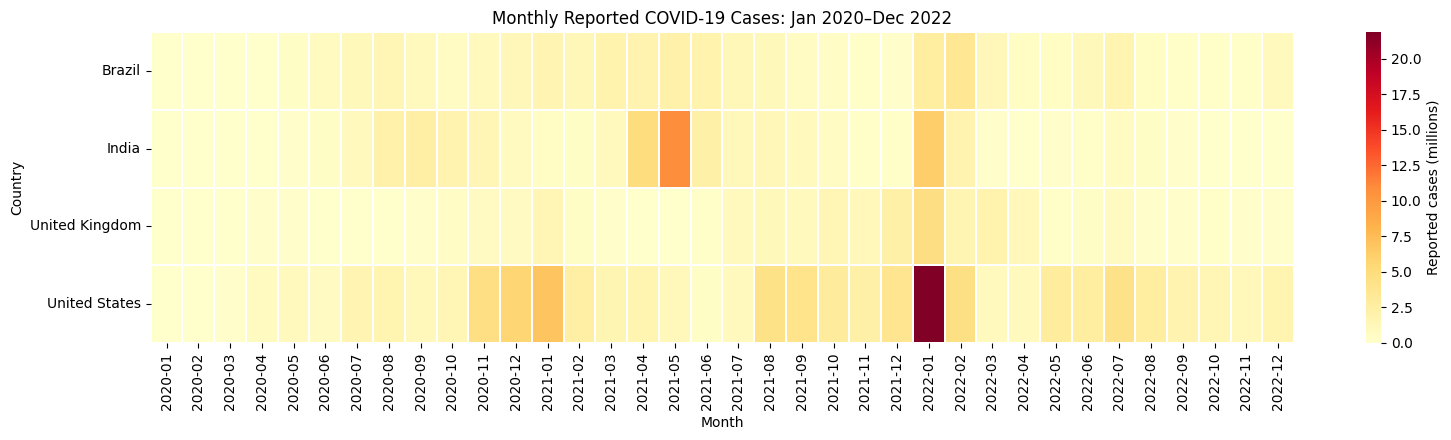

In [34]:
d['month'] = d['date'].dt.to_period('M').astype(str)
monthly = (
    d.groupby(['location', 'month'])['new_cases']
     .sum(min_count=1)
     .reset_index()
)

pivot = monthly.pivot(index='location', columns='month', values='new_cases')
pivot = pivot.loc[:, '2020-01':'2022-12']

plt.figure(figsize=(16, 4.5))
sns.heatmap(pivot / 1e6, cmap='YlOrRd', linewidths=0.2,
            cbar_kws={'label': 'Reported cases (millions)'})
plt.title('Monthly Reported COVID-19 Cases: Jan 2020–Dec 2022')
plt.xlabel('Month')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [35]:
plot_df = summary.loc[countries, ['Before', 'After']].reset_index().melt(
    id_vars='location', var_name='Period', value_name='Median CFR (%)'
)

fig = px.bar(
    plot_df, x='location', y='Median CFR (%)', color='Period', barmode='group',
    text='Median CFR (%)',
    title='Median Daily Case Fatality Rate: Before vs After',
    labels={'location': 'Country'},
    template='plotly_white'
)
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(height=500)
fig.show()

In [36]:
fig = px.line(
    d[d['date'] >= '2020-06-01'],
    x='date', y='daily_cfr', color='location',
    title='Smoothed Daily Case Fatality Rate Over Time',
    labels={'daily_cfr': 'Daily CFR (%)', 'date': 'Date', 'location': 'Country'},
    template='plotly_white'
)
fig.add_vline(x=pd.Timestamp('2021-01-01'), line_dash='dash', line_color='gray')
fig.update_yaxes(rangemode='tozero')
fig.update_layout(height=520)
fig.show()

In [37]:
scatter_df = d[['location', 'date', 'people_fully_vaccinated_per_hundred', 'daily_cfr']].dropna().copy()

fig = px.scatter(
    scatter_df,
    x='people_fully_vaccinated_per_hundred',
    y='daily_cfr',
    color='location',
    hover_data=['date'],
    opacity=0.45,
    title='Vaccination Coverage vs Smoothed Daily CFR',
    labels={
        'people_fully_vaccinated_per_hundred': 'People fully vaccinated (%)',
        'daily_cfr': 'Daily CFR (%)',
        'location': 'Country'
    },
    template='plotly_white'
)
fig.update_layout(height=520)
fig.show()